# Bayesian Network Structure Learning — POC Experiment

Compares **Hill Climbing** (pgmpy) against **NOTEARS** (gcastle) in two feature regimes:
- Low-dimensional: 10 features, 1000 samples
- High-dimensional: 100 features, 1000 samples

Each dataset is split 90/10 into train/test. We measure wall-clock time for structure learning.

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from data import *
from reporting import graph_metrics
from training import *


SEED = 42


In [15]:
sachs_df, sachs_dag  = load_sachs()
print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")

sachs_notears_result = train_notears(sachs_df, lambda1=0.5, w_threshold=0.5)
sachs_notears_metrics = graph_metrics(sachs_dag.edges, sachs_notears_result.edges)

sachs_hc_result = train_hill_climbing(sachs_df)
sachs_hc_metrics = graph_metrics(sachs_dag.edges, sachs_hc_result.edges)
sachs_pc_result = train_pc(sachs_df, ci_test="pearsonr", significance_level=0.001, max_cond_vars=None)
sachs_pc_metrics = graph_metrics(sachs_dag.edges, sachs_pc_result.edges)
sachs_fges_result = train_fges(sachs_df, method="r2")
sachs_fges_metrics = graph_metrics(sachs_dag.edges, sachs_fges_result.edges)


2026-06-29 14:17:51,598 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=11672, d=11, iter_=100, h_=1e-08, rho_=10000000000000000


Sachs: 11672 samples, 11 nodes, 20 true edges


2026-06-29 14:17:55,588 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.493e+00, loss=543643.397, rho=1.0e+00
2026-06-29 14:17:58,590 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.491e+00, loss=259313.685, rho=1.0e+00
2026-06-29 14:18:01,495 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.463e+00, loss=259341.664, rho=1.0e+01
2026-06-29 14:18:04,402 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.252e+00, loss=259621.452, rho=1.0e+02
2026-06-29 14:18:07,241 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

In [16]:
CANCER_SAMPLES = 1000
cancer_df, cancer_dag  = load_cancer(CANCER_SAMPLES, seed=SEED)
print(f"cancer: {cancer_df.shape[0]} samples, {cancer_df.shape[1]} nodes, {len(cancer_dag.edges())} true edges")

cancer_notears_result = train_notears(cancer_df, lambda1=0.5, w_threshold=0.5)
cancer_notears_metrics = graph_metrics(cancer_dag.edges, cancer_notears_result.edges)

cancer_hc_result = train_hill_climbing(cancer_df)
cancer_hc_metrics = graph_metrics(cancer_dag.edges, cancer_hc_result.edges)
cancer_pc_result = train_pc(cancer_df, ci_test="pearsonr", significance_level=0.001, max_cond_vars=None)
cancer_pc_metrics = graph_metrics(cancer_dag.edges, cancer_pc_result.edges)
cancer_fges_result = train_fges(cancer_df, method="r2")
cancer_fges_metrics = graph_metrics(cancer_dag.edges, cancer_fges_result.edges)


Generating for node: Dyspnoea: 100%|██████████| 5/5 [00:00<00:00, 722.16it/s]
2026-06-29 14:20:06,890 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=5, iter_=100, h_=1e-08, rho_=10000000000000000
2026-06-29 14:20:06,892 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=0.000e+00, loss=0.347, rho=1.0e+00
2026-06-29 14:20:06,892 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:222] - INFO: FINISHED
/home/danie/codice/uni/bayesian-continuous/training.py:41: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  estimator = HillClimbSearch(data)
2026-06-29 14:20:06,893 - /home/danie/codice/uni/bayesian-

cancer: 1000 samples, 5 nodes, 4 true edges


  0%|          | 4/1000000 [00:00<13:52:58, 20.01it/s]


In [17]:
CHILD_SAMPLES = 10000
child_df, child_dag  = load_child(CHILD_SAMPLES, seed=SEED)
print(f"child: {child_df.shape[0]} samples, {child_df.shape[1]} nodes, {len(child_dag.edges())} true edges")

child_notears_result = train_notears(child_df, lambda1=0.5, w_threshold=0.5)
child_notears_metrics = graph_metrics(child_dag.edges, child_notears_result.edges)

child_hc_result = train_hill_climbing(child_df)
child_hc_metrics = graph_metrics(child_dag.edges, child_hc_result.edges)
child_pc_result = train_pc(child_df, ci_test="pearsonr", significance_level=0.001, max_cond_vars=None)
child_pc_metrics = graph_metrics(child_dag.edges, child_pc_result.edges)
child_fges_result = train_fges(child_df, method="r2")
child_fges_metrics = graph_metrics(child_dag.edges, child_fges_result.edges)



Generating for node: ChestXray:   0%|          | 0/20 [00:00<?, ?it/s]  2026-06-29 14:20:07,892 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: -2.220446049250313e-16. Adjusting values.
2026-06-29 14:20:07,893 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: 2.220446049250313e-16. Adjusting values.
Generating for node: GruntingReport: 100%|██████████| 20/20 [00:00<00:00, 163.75it/s]
2026-06-29 14:20:07,965 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=10000, d=20, iter_=100, h_=1e-08, rho_=10000000000000000
2026-06-29 14:20:08,108 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/

child: 10000 samples, 20 nodes, 25 true edges


2026-06-29 14:20:08,197 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=6.480e-02, loss=6.462, rho=1.0e+00
2026-06-29 14:20:08,305 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=5.056e-02, loss=6.482, rho=1.0e+01
2026-06-29 14:20:08,592 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.507e-02, loss=6.688, rho=1.0e+02
2026-06-29 14:20:08,871 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.527e-03, loss=8.747, rho=1.0e+03
2026-06-29 14:20:09,445 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

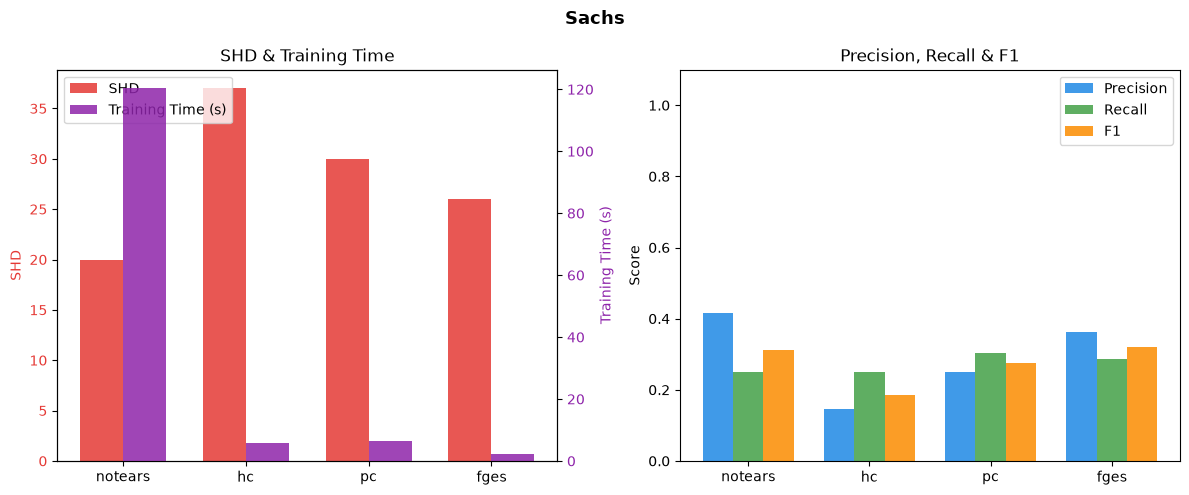

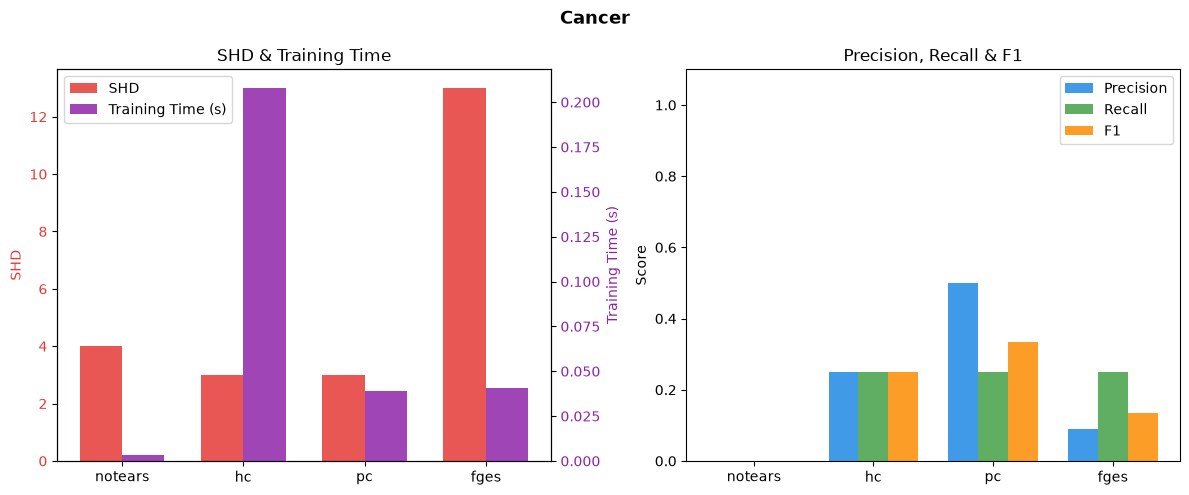

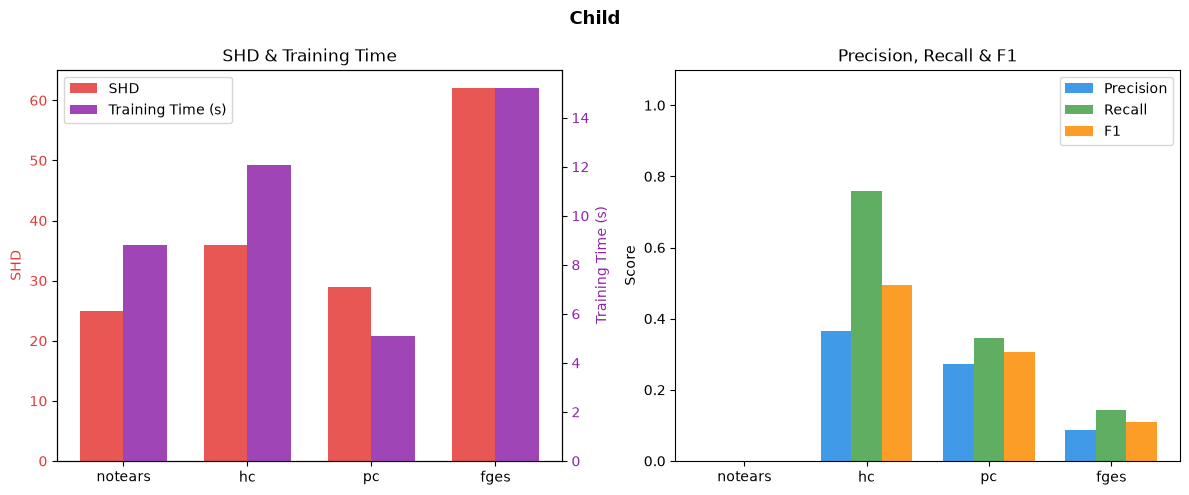

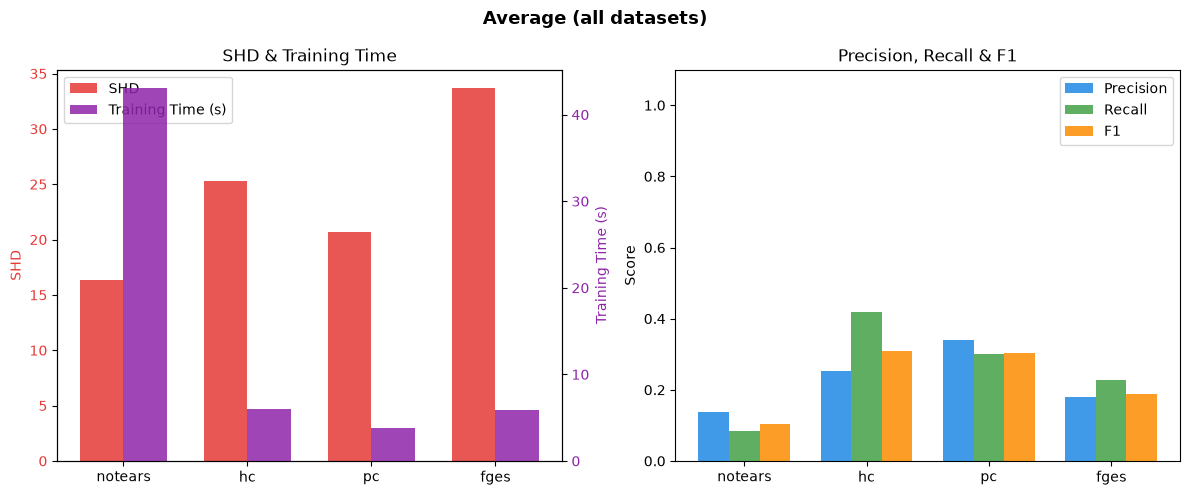

In [18]:
datasets = {
    "Sachs": {
        "notears": (sachs_notears_metrics,  sachs_notears_result.elapsed_s),
        "hc":      (sachs_hc_metrics,       sachs_hc_result.elapsed_s),
        "pc":      (sachs_pc_metrics,       sachs_pc_result.elapsed_s),
        "fges":    (sachs_fges_metrics,     sachs_fges_result.elapsed_s),
    },
    "Cancer": {
        "notears": (cancer_notears_metrics, cancer_notears_result.elapsed_s),
        "hc":      (cancer_hc_metrics,      cancer_hc_result.elapsed_s),
        "pc":      (cancer_pc_metrics,      cancer_pc_result.elapsed_s),
        "fges":    (cancer_fges_metrics,    cancer_fges_result.elapsed_s),
    },
    "Child": {
        "notears": (child_notears_metrics,  child_notears_result.elapsed_s),
        "hc":      (child_hc_metrics,       child_hc_result.elapsed_s),
        "pc":      (child_pc_metrics,       child_pc_result.elapsed_s),
        "fges":    (child_fges_metrics,     child_fges_result.elapsed_s),
    },
}

ALGORITHMS  = ["notears", "hc", "pc", "fges"]
SHD_COLOR   = "#E53935"
TIME_COLOR  = "#8E24AA"
PRF_COLORS  = {"precision": "#1E88E5", "recall": "#43A047", "f1": "#FB8C00"}


def _plot_dataset(title, algo_data):
    fig, (ax_shd_time, ax_prf) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    x = np.arange(len(ALGORITHMS))
    w = 0.35

    # left: SHD (left axis) + training time (right axis)
    ax_time = ax_shd_time.twinx()

    shd_vals  = [algo_data[a][0]["shd"] for a in ALGORITHMS]
    time_vals = [algo_data[a][1]        for a in ALGORITHMS]

    b_shd  = ax_shd_time.bar(x - w / 2, shd_vals,  w, color=SHD_COLOR,  alpha=0.85, label="SHD")
    b_time = ax_time.bar(    x + w / 2, time_vals, w, color=TIME_COLOR, alpha=0.85, label="Training Time (s)")

    ax_shd_time.set_xticks(x)
    ax_shd_time.set_xticklabels(ALGORITHMS)
    ax_shd_time.set_ylabel("SHD",              color=SHD_COLOR)
    ax_shd_time.tick_params(axis="y",           labelcolor=SHD_COLOR)
    ax_time.set_ylabel("Training Time (s)",     color=TIME_COLOR)
    ax_time.tick_params(axis="y",               labelcolor=TIME_COLOR)
    ax_shd_time.set_title("SHD & Training Time")
    ax_shd_time.legend(handles=[b_shd, b_time], loc="upper left")

    # right: precision, recall, F1 ---
    w3 = 0.25
    offsets = [-w3, 0, w3]
    for (metric, color), offset in zip(PRF_COLORS.items(), offsets):
        vals = [algo_data[a][0][metric] for a in ALGORITHMS]
        ax_prf.bar(x + offset, vals, w3, color=color, alpha=0.85, label=metric.capitalize())

    ax_prf.set_xticks(x)
    ax_prf.set_xticklabels(ALGORITHMS)
    ax_prf.set_ylabel("Score")
    ax_prf.set_ylim(0, 1.1)
    ax_prf.set_title("Precision, Recall & F1")
    ax_prf.legend()

    fig.tight_layout()
    plt.show()


for name, algo_data in datasets.items():
    _plot_dataset(name, algo_data)

# aggregate figure
avg_data = {
    algo: (
        {m: np.mean([datasets[ds][algo][0][m] for ds in datasets])
         for m in ["shd", "precision", "recall", "f1"]},
        np.mean([datasets[ds][algo][1] for ds in datasets]),
    )
    for algo in ALGORITHMS
}
_plot_dataset("Average (all datasets)", avg_data)
